# Duomenys ir žvalgomoji analizė — paveikslai bakalauro darbui

Notebookas generuoja visus skyriaus *Duomenys ir žvalgomoji analizė* paveikslus:

- **EDA-1.** Vidutiniai pavienių žvaigždžių ir dvinarių sistemų Gaia XP spektrai.
- **EDA-2.** Po vieną realią pavienę ir dvinarę žvaigždę.
- **EDA-3.** Klasių pasiskirstymas (lentelė + iliustracinis stulpelinis grafikas).
- **EDA-4.** Vienos žvaigždės BP spektras: Čebiševo bazės aproksimacija prie skirtingų K.
- **EDA-5.** Ta pati žvaigždė, K = 20, trijų bazių aproksimacijos.
- **EDA-6.** Vidutinis aproksimacijos R² priklausomai nuo K (po vieną kreivę kiekvienai bazei).
- **EDA-7.** Empirinės koeficientų koreliacijos matricos (Čebiševas, Ležandras, B-splainai).

Kiekvienas paveikslas išsaugomas ir kaip `.png` (300 dpi), ir kaip `.svg` aplanke `thesis_figures/eda/`. Kiekvienos figūros ląstelę galima paleisti atskirai.

Pastaba: B-splainų projekcijos skaičiavimas naudoja tą patį `bspline_design_matrix` iš `02_generate_basis_features.py`, kuris naudojamas klasifikacijos eksperimente — todėl EDA matricos ir klasifikatoriaus bruožai yra suderinti.

## 0. Aplinkos paruošimas, duomenų įkėlimas, parametrai

In [86]:
from __future__ import annotations

import sys
from importlib.util import module_from_spec, spec_from_file_location
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

NOTEBOOK_DIR = Path.cwd()
WORKSPACE_ROOT = NOTEBOOK_DIR.parent
THESIS_FIG_DIR = WORKSPACE_ROOT / "thesis_figures"
EDA_OUT_DIR = THESIS_FIG_DIR / "eda"
EDA_OUT_DIR.mkdir(parents=True, exist_ok=True)

if str(THESIS_FIG_DIR) not in sys.path:
    sys.path.insert(0, str(THESIS_FIG_DIR))
if str(NOTEBOOK_DIR) not in sys.path:
    sys.path.insert(0, str(NOTEBOOK_DIR))

import importlib
import plot_style
importlib.reload(plot_style)
ps = plot_style
ps.set_rc_defaults()

from _common import BP_SAMPLED_CSV, RP_SAMPLED_CSV, l2_normalize

STEP02_PATH = NOTEBOOK_DIR / "02_generate_basis_features.py"
_spec = spec_from_file_location("bp_basis_step02", STEP02_PATH)
step02 = module_from_spec(_spec)
assert _spec.loader is not None
sys.modules[_spec.name] = step02
_spec.loader.exec_module(step02)

print("Stiliaus modulis:", ps.__file__)
print("Pipeline'o modulis:", STEP02_PATH)

Stiliaus modulis: /Users/erikak/Documents/uni/bakalauras/kodas/thesis_figures/plot_style.py
Pipeline'o modulis: /Users/erikak/Documents/uni/bakalauras/kodas/bp_rp_basis_experiment/02_generate_basis_features.py


In [87]:
JOINT_XP_CSV = WORKSPACE_ROOT / "transformation_poc" / "xp_sampled_spectra.csv"

for path in (BP_SAMPLED_CSV, RP_SAMPLED_CSV, JOINT_XP_CSV):
    if not Path(path).exists():
        raise FileNotFoundError(
            f"Trūksta įvesties failo: {path}. Patikrinkite pipeline'o žingsnį "
            f"`01_prepare_inputs.ipynb` bei `transformation_poc/` katalogą."
        )

bp = step02.load_block(BP_SAMPLED_CSV)
rp = step02.load_block(RP_SAMPLED_CSV)
step02.check_alignment(bp, rp)

df_xp = pd.read_csv(JOINT_XP_CSV)
xp_wl_cols = [c for c in df_xp.columns if c.startswith("wl_")]
xp_wavelengths = np.asarray([float(c.split("_", 1)[1]) for c in xp_wl_cols], dtype=float)

df_xp_aligned = df_xp.set_index("source_id").reindex(bp.source_ids)
missing_in_joint = df_xp_aligned[xp_wl_cols].isna().any(axis=1).sum()
if missing_in_joint:
    raise ValueError(
        f"{missing_in_joint} BP/RP žvaigždžių neturi atitikmens jungtiniame XP "
        f"faile {JOINT_XP_CSV}. Negalime tęsti be tikrų duomenų."
    )
xp_flux_matrix = df_xp_aligned[xp_wl_cols].to_numpy(dtype=float)
xp_labels = bp.labels.copy()
xp_source_ids = bp.source_ids.copy()

n_total = int(xp_flux_matrix.shape[0])
n_binary = int((xp_labels == 1).sum())
n_single = int((xp_labels == 0).sum())

print(f"BP arm:    {bp.flux.shape[0]} žvaigždžių, {bp.flux.shape[1]} bangos ilgių "
      f"({bp.wavelengths[0]:.0f}\u2013{bp.wavelengths[-1]:.0f} nm)")
print(f"RP arm:    {rp.flux.shape[0]} žvaigždžių, {rp.flux.shape[1]} bangos ilgių "
      f"({rp.wavelengths[0]:.0f}\u2013{rp.wavelengths[-1]:.0f} nm)")
print(f"Jungtinis: {n_total} žvaigždžių, {len(xp_wavelengths)} bangos ilgių "
      f"({xp_wavelengths[0]:.0f}\u2013{xp_wavelengths[-1]:.0f} nm)")
print(f"Pavienės (y=0): {n_single} | dvinarės (y=1): {n_binary} | iš viso: {n_total}")

BP arm:    2815 žvaigždžių, 154 bangos ilgių (336–642 nm)
RP arm:    2815 žvaigždžių, 193 bangos ilgių (636–1020 nm)
Jungtinis: 2815 žvaigždžių, 343 bangos ilgių (336–1020 nm)
Pavienės (y=0): 2257 | dvinarės (y=1): 558 | iš viso: 2815


In [88]:
RNG_SEED = 42

def pick_representative(label: int) -> tuple[int, float]:
    """Return the source_id of the star whose L2-normalised XP spectrum is
    closest (Euclidean distance) to its class mean, plus that distance.

    Deterministic: the same star is always returned for the same data.
    """
    pool = np.flatnonzero(xp_labels == label)
    spectra = xp_flux_matrix[pool]
    norms = np.linalg.norm(spectra, axis=1, keepdims=True)
    norms = np.where(norms > 0, norms, 1.0)
    spectra_l2 = spectra / norms
    class_mean = spectra_l2.mean(axis=0)
    dists = np.linalg.norm(spectra_l2 - class_mean, axis=1)
    best_in_pool = int(np.argmin(dists))
    best_row = int(pool[best_in_pool])
    return int(xp_source_ids[best_row]), float(dists[best_in_pool])

_single_id, _single_dist = pick_representative(0)
_binary_id, _binary_dist = pick_representative(1)
EXAMPLE_SINGLE_SOURCE_ID = _single_id
EXAMPLE_BINARY_SOURCE_ID = _binary_id

K_LIST_FOR_EDA4 = [2, 5, 10, 20]
K_FIXED = 20
K_GRID_FOR_EDA6 = [2, 5, 10, 15, 20]
BASES = ("chebyshev", "legendre", "bspline")

def row_index(block, source_id: int) -> int:
    matches = np.flatnonzero(block.source_ids == int(source_id))
    if not len(matches):
        raise ValueError(f"source_id={source_id} nerastas duomenyse")
    return int(matches[0])

_idx_single = row_index(bp, EXAMPLE_SINGLE_SOURCE_ID)
_idx_binary = row_index(bp, EXAMPLE_BINARY_SOURCE_ID)

print("Pavyzdinės žvaigždės parinktos pagal mažiausią L2 atstumą iki klasės vidurkio:")
print(f"  Pavienė (EDA-2/4/5): source_id = {EXAMPLE_SINGLE_SOURCE_ID} "
      f"(y=0, atstumas iki vidurkio = {_single_dist:.4f})")
print(f"  Dvinarė (EDA-2):     source_id = {EXAMPLE_BINARY_SOURCE_ID} "
      f"(y=1, atstumas iki vidurkio = {_binary_dist:.4f})")
print(f"K reikšmių sąrašas EDA-4: {K_LIST_FOR_EDA4}")
print(f"K reikšmių sąrašas EDA-6: {K_GRID_FOR_EDA6}")
print(f"Fiksuotas K (EDA-5/7): {K_FIXED}")

Pavyzdinės žvaigždės parinktos pagal mažiausią L2 atstumą iki klasės vidurkio:
  Pavienė (EDA-2/4/5): source_id = 5447021565108738688 (y=0, atstumas iki vidurkio = 0.0201)
  Dvinarė (EDA-2):     source_id = 6587335519633433472 (y=1, atstumas iki vidurkio = 0.0149)
K reikšmių sąrašas EDA-4: [2, 5, 10, 20]
K reikšmių sąrašas EDA-6: [2, 5, 10, 15, 20]
Fiksuotas K (EDA-5/7): 20


## EDA-1. Vidutiniai pavienių žvaigždžių ir dvinarių sistemų XP spektrai

Viršutinis skydelis: pavienių (y = 0) ir dvinarių (y = 1) Gaia XP spektrų vidurkiai jungtinėje 336–1020 nm tinklelyje (logaritminė y skalė, kad būtų matomi abu galai). Apatinis skydelis: dvinarių vidurkio santykis su pavienių vidurkiu — santykis kyla nuo ~0,5 mėlynojoje pusėje iki ~0,9 ties 1 000 nm, t. y. dvinarės sistemos pasižymi raudonojo galo srauto pertekliumi (>700 nm sritis pažymėta pilkai).

Paveikslo pavadinimas (kopijuoti į LaTeX caption):
  Vidutiniai pavienių žvaigždžių ir dvinarių sistemų Gaia XP spektrai



/var/folders/4r/q16blmjs6pgd376n_t3lqthw0000gn/T/ipykernel_90445/2412348322.py:79: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


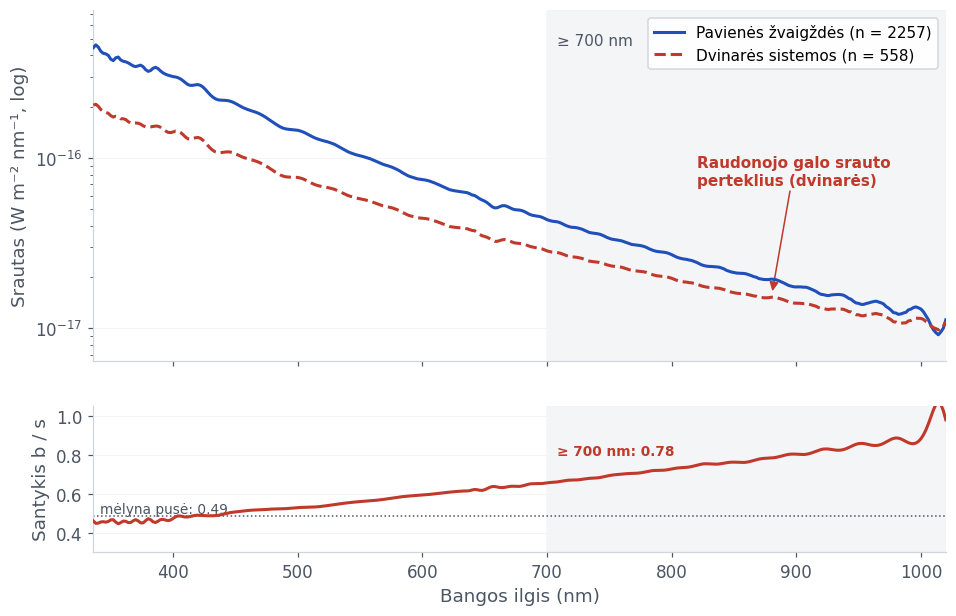

Išsaugota: /Users/erikak/Documents/uni/bakalauras/kodas/thesis_figures/eda/eda-1_mean_spectra.png
Išsaugota: /Users/erikak/Documents/uni/bakalauras/kodas/thesis_figures/eda/eda-1_mean_spectra.svg


In [89]:
mean_single = xp_flux_matrix[xp_labels == 0].mean(axis=0)
mean_binary = xp_flux_matrix[xp_labels == 1].mean(axis=0)

ratio_b_over_s = np.where(mean_single > 0, mean_binary / mean_single, np.nan)

RED_EXCESS_LO = 700.0
red_mask = xp_wavelengths >= RED_EXCESS_LO
blue_ratio = float(np.nanmean(ratio_b_over_s[xp_wavelengths < 500.0]))
red_ratio = float(np.nanmean(ratio_b_over_s[red_mask]))

fig, (ax_top, ax_bot) = plt.subplots(
    2, 1, figsize=(10, 6.4), sharex=True,
    gridspec_kw={"height_ratios": [2.4, 1.0], "hspace": 0.18},
)

for ax in (ax_top, ax_bot):
    ax.axvspan(RED_EXCESS_LO, xp_wavelengths[-1],
               color=ps.GRID_GRAY, alpha=0.85, zorder=0)

ax_top.plot(xp_wavelengths, mean_single,
            color=ps.COLORS["single"], linewidth=2.0, linestyle="-",
            label=f"Pavienės žvaigždės (n = {n_single})", zorder=4)
ax_top.plot(xp_wavelengths, mean_binary,
            color=ps.COLORS["binary"], linewidth=2.0, linestyle="--",
            label=f"Dvinarės sistemos (n = {n_binary})", zorder=4)

ax_top.set_yscale("log")
ax_top.set_xlim(xp_wavelengths[0], xp_wavelengths[-1])
y_min = min(mean_single.min(), mean_binary.min())
y_max = max(mean_single.max(), mean_binary.max())
ax_top.set_ylim(y_min * 0.7, y_max * 1.6)

ax_top.text(RED_EXCESS_LO + 8, y_max * 1.18, "\u2265 700 nm",
            fontsize=10, color=ps.TEXT_MUTED, va="top")

ax_top.annotate(
    "Raudonojo galo srauto\nperteklius (dvinarės)",
    xy=(880.0, mean_binary[int(np.argmin(np.abs(xp_wavelengths - 880.0)))]),
    xytext=(820.0, y_max * 0.18),
    fontsize=10, color=ps.COLORS["binary"], fontweight="bold",
    ha="left", va="center",
    arrowprops=dict(arrowstyle="-|>", color=ps.COLORS["binary"],
                    linewidth=1.0, shrinkA=0, shrinkB=4,
                    mutation_scale=12),
)

ax_bot.plot(xp_wavelengths, ratio_b_over_s,
            color=ps.COLORS["binary"], linewidth=2.0, linestyle="-",
            label="Vidutinis dvinarių/pavienių srauto santykis", zorder=4)
ax_bot.axhline(blue_ratio, color=ps.TEXT_MUTED, linestyle=":",
               linewidth=1.0, zorder=2)
ax_bot.text(
    xp_wavelengths[0] + 5, blue_ratio,
    f"mėlyna pusė: {blue_ratio:.2f}",
    fontsize=9, color=ps.TEXT_MUTED, va="bottom", ha="left",
)
ax_bot.text(
    RED_EXCESS_LO + 8, red_ratio,
    f"\u2265 700 nm: {red_ratio:.2f}",
    fontsize=9, color=ps.COLORS["binary"], fontweight="bold",
    va="bottom", ha="left",
)

ax_bot.set_ylim(0.3, 1.05)
ax_bot.set_xlim(xp_wavelengths[0], xp_wavelengths[-1])

ps.apply_style(ax_top, grid_axis="y")
ps.apply_style(ax_bot, grid_axis="y")

ax_top.set_ylabel("Srautas (W m\u207b\u00b2 nm\u207b\u00b9, log)",
                  fontsize=12, color=ps.TEXT_MUTED)
ax_bot.set_ylabel("Santykis b / s",
                  fontsize=12, color=ps.TEXT_MUTED)
ax_bot.set_xlabel("Bangos ilgis (nm)", fontsize=12, color=ps.TEXT_MUTED)

ax_top.legend(loc="upper right", fontsize=10, frameon=True,
              framealpha=0.95, edgecolor=ps.AXIS_GRAY)

fig.tight_layout()

EDA1_TITLE = "Vidutiniai pavienių žvaigždžių ir dvinarių sistemų Gaia XP spektrai"
print(f"Paveikslo pavadinimas (kopijuoti į LaTeX caption):\n  {EDA1_TITLE}\n")

paths = ps.save_fig(fig, "eda-1_mean_spectra")
plt.show()
for p in paths:
    print("Išsaugota:", p)

## EDA-1b. Individualūs spektrai su klasių vidurkiais (L2 normalizuoti)

Alternatyvi EDA-1 versija: kiekvienos klasės atsitiktinai parinkti individualūs Gaia XP spektrai (336–1020 nm, jungtinis BP + RP segmentas) atvaizduojami plonomis permatomomis linijomis, o ant viršaus ryškiomis linijomis užtepami klasių **vidurkiai**. Spektrai L2 normalizuoti per eilutę, todėl klasių formos skirtumas (mėlyna pusė ↔ raudona pusė) tampa lengvai matomas, o pavyzdinių žvaigždžių sklaida — irgi iškart pajaučiama.

Paveikslo pavadinimas (kopijuoti į LaTeX caption):
  Gaia XP spektrai pagal klases ir jų vidurkiai



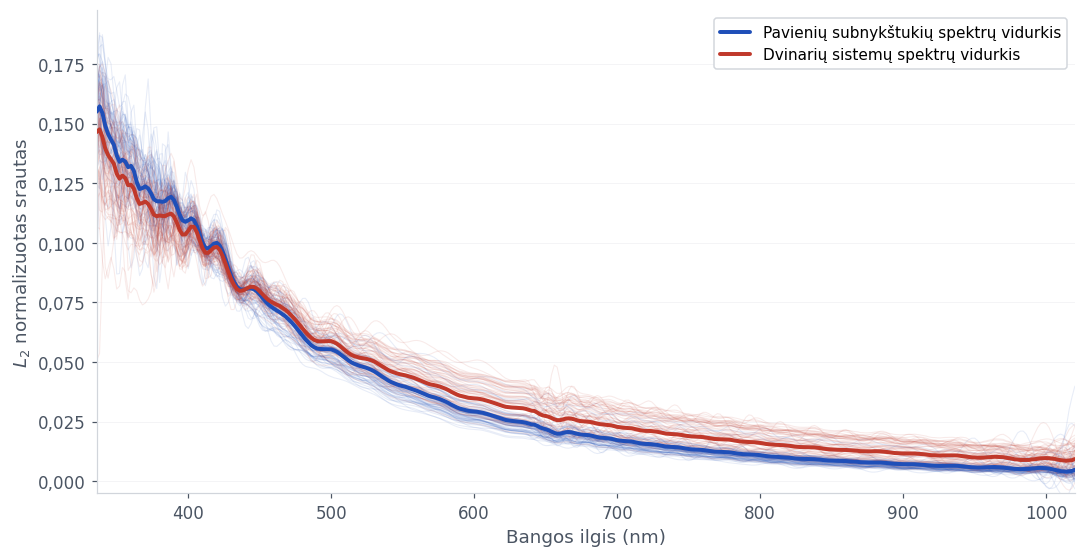

Išsaugota: /Users/erikak/Documents/uni/bakalauras/kodas/thesis_figures/eda/eda-1b_individual_spectra_overlay.png
Išsaugota: /Users/erikak/Documents/uni/bakalauras/kodas/thesis_figures/eda/eda-1b_individual_spectra_overlay.svg


In [90]:
xp_row_norms = np.linalg.norm(xp_flux_matrix, axis=1, keepdims=True)
xp_row_norms = np.where(xp_row_norms > 0, xp_row_norms, 1.0)
xp_l2_matrix = xp_flux_matrix / xp_row_norms

mean_single_l2 = xp_l2_matrix[xp_labels == 0].mean(axis=0)
mean_binary_l2 = xp_l2_matrix[xp_labels == 1].mean(axis=0)

N_SAMPLE_PER_CLASS = 60
_rng_eda1b = np.random.default_rng(RNG_SEED)
single_pool = np.flatnonzero(xp_labels == 0)
binary_pool = np.flatnonzero(xp_labels == 1)
single_sample = _rng_eda1b.choice(single_pool,
                                  size=min(N_SAMPLE_PER_CLASS, len(single_pool)),
                                  replace=False)
binary_sample = _rng_eda1b.choice(binary_pool,
                                  size=min(N_SAMPLE_PER_CLASS, len(binary_pool)),
                                  replace=False)

fig, ax = plt.subplots(figsize=(10, 5.2))

for i in single_sample:
    ax.plot(xp_wavelengths, xp_l2_matrix[i],
            color=ps.COLORS["single"], alpha=0.10,
            linewidth=0.7, zorder=2)
for i in binary_sample:
    ax.plot(xp_wavelengths, xp_l2_matrix[i],
            color=ps.COLORS["binary"], alpha=0.10,
            linewidth=0.7, zorder=2)

ax.plot(xp_wavelengths, mean_single_l2,
        color=ps.COLORS["single"], linewidth=2.6, linestyle="-",
        label="Pavienių subnykštukių spektrų vidurkis",
        solid_capstyle="round", zorder=5)
ax.plot(xp_wavelengths, mean_binary_l2,
        color=ps.COLORS["binary"], linewidth=2.6, linestyle="-",
        label="Dvinarių sistemų spektrų vidurkis",
        solid_capstyle="round", zorder=5)

ax.set_xlim(xp_wavelengths[0], xp_wavelengths[-1])
y_lo = float(min(mean_single_l2.min(), mean_binary_l2.min(),
                 np.percentile(xp_l2_matrix[np.r_[single_sample, binary_sample]], 1)))
y_hi = float(max(xp_l2_matrix[np.r_[single_sample, binary_sample]].max(),
                 mean_single_l2.max(), mean_binary_l2.max()))
ax.set_ylim(min(y_lo, 0.0) - 0.005, y_hi * 1.05)

ps.finalise(
    fig, ax,
    xlabel="Bangos ilgis (nm)",
    ylabel="$L_2$ normalizuotas srautas",
)
ax.yaxis.set_major_formatter(ps.lt_comma_formatter(decimals=3))
ax.legend(loc="upper right", fontsize=10, frameon=True,
          framealpha=0.95, edgecolor=ps.AXIS_GRAY)

EDA1B_TITLE = "Gaia XP spektrai pagal klases ir jų vidurkiai"
print(f"Paveikslo pavadinimas (kopijuoti į LaTeX caption):\n  {EDA1B_TITLE}\n")

paths = ps.save_fig(fig, "eda-1b_individual_spectra_overlay")
plt.show()
for p in paths:
    print("Išsaugota:", p)

### EDA-1c. Klasifikacijos signalo sritis paryškinta (≥ 700 nm)

Tas pats vaizdas kaip EDA-1b, tik pažymėta klasifikacijos signalo sritis (≥ 700 nm): šioje juostoje pasireiškia dvinarių sistemų raudonojo galo srauto perteklius, t. y. pagrindinis pirminis signalas, kuriuo naudojasi klasifikatorius. Sritis išryškinta švelnia juosta, o tarp klasių vidurkių užtepamas plonas spalvotas sluoksnis, leidžiantis pamatyti spragą.

Paveikslo pavadinimas (kopijuoti į LaTeX caption):
  Gaia XP spektrai pagal klases ir jų vidurkiai su pažymėta klasifikacijos signalo riba ties 700 nm



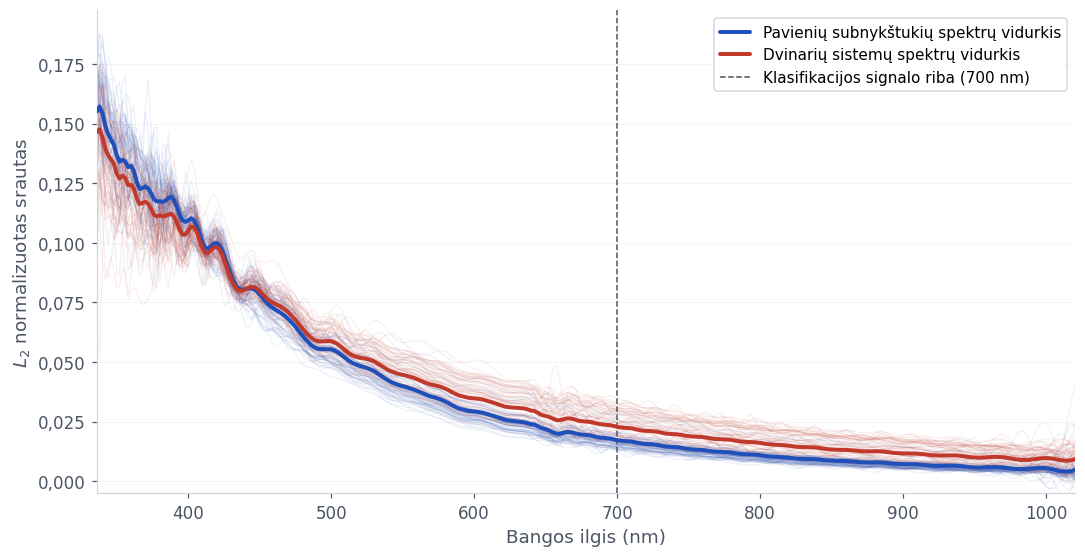

Išsaugota: /Users/erikak/Documents/uni/bakalauras/kodas/thesis_figures/eda/eda-1c_individual_spectra_signal_region.png
Išsaugota: /Users/erikak/Documents/uni/bakalauras/kodas/thesis_figures/eda/eda-1c_individual_spectra_signal_region.svg


In [91]:
SIGNAL_LO = 700.0

fig, ax = plt.subplots(figsize=(10, 5.2))

for i in single_sample:
    ax.plot(xp_wavelengths, xp_l2_matrix[i],
            color=ps.COLORS["single"], alpha=0.09,
            linewidth=0.7, zorder=2)
for i in binary_sample:
    ax.plot(xp_wavelengths, xp_l2_matrix[i],
            color=ps.COLORS["binary"], alpha=0.09,
            linewidth=0.7, zorder=2)

ax.plot(xp_wavelengths, mean_single_l2,
        color=ps.COLORS["single"], linewidth=2.6, linestyle="-",
        label="Pavienių subnykštukių spektrų vidurkis",
        solid_capstyle="round", zorder=5)
ax.plot(xp_wavelengths, mean_binary_l2,
        color=ps.COLORS["binary"], linewidth=2.6, linestyle="-",
        label="Dvinarių sistemų spektrų vidurkis",
        solid_capstyle="round", zorder=5)

ax.set_xlim(xp_wavelengths[0], xp_wavelengths[-1])
y_lo = float(min(mean_single_l2.min(), mean_binary_l2.min(),
                 np.percentile(xp_l2_matrix[np.r_[single_sample, binary_sample]], 1)))
y_hi = float(max(xp_l2_matrix[np.r_[single_sample, binary_sample]].max(),
                 mean_single_l2.max(), mean_binary_l2.max()))
y_bot = min(y_lo, 0.0) - 0.005
y_top = y_hi * 1.05
ax.set_ylim(y_bot, y_top)

ax.axvline(SIGNAL_LO, color=ps.TEXT_MUTED, linewidth=1.0,
           linestyle="--", zorder=4,
           label="Klasifikacijos signalo riba (700 nm)")

ps.finalise(
    fig, ax,
    xlabel="Bangos ilgis (nm)",
    ylabel="$L_2$ normalizuotas srautas",
)
ax.yaxis.set_major_formatter(ps.lt_comma_formatter(decimals=3))
ax.legend(loc="upper right", fontsize=10, frameon=True,
          framealpha=0.95, edgecolor=ps.AXIS_GRAY)

EDA1C_TITLE = (
    "Gaia XP spektrai pagal klases ir jų vidurkiai su pažymėta "
    "klasifikacijos signalo riba ties 700 nm"
)
print(f"Paveikslo pavadinimas (kopijuoti į LaTeX caption):\n  {EDA1C_TITLE}\n")

paths = ps.save_fig(fig, "eda-1c_individual_spectra_signal_region")
plt.show()
for p in paths:
    print("Išsaugota:", p)

### EDA-1d. Tas pats vaizdas neperskaičiuotų (absoliutaus) srautų skalėje

Toks pat išdėstymas kaip EDA-1c, tačiau spektrai pateikiami originalia kalibruoto srauto skale (W m⁻² nm⁻¹), be eilutei taikomos L2 normalizacijos. Šis variantas leidžia matyti absoliutaus srauto skirtumus tarp klasių; pagrindinis klasifikacijos signalas (≥ 700 nm) pažymėtas tokia pat juosta kaip ir L2 versijoje.

Paveikslo pavadinimas (kopijuoti į LaTeX caption):
  Gaia XP spektrai pagal klases ir jų vidurkiai (absoliutaus srauto skalė) su klasifikacijos signalo sritimi (≥ 700 nm)



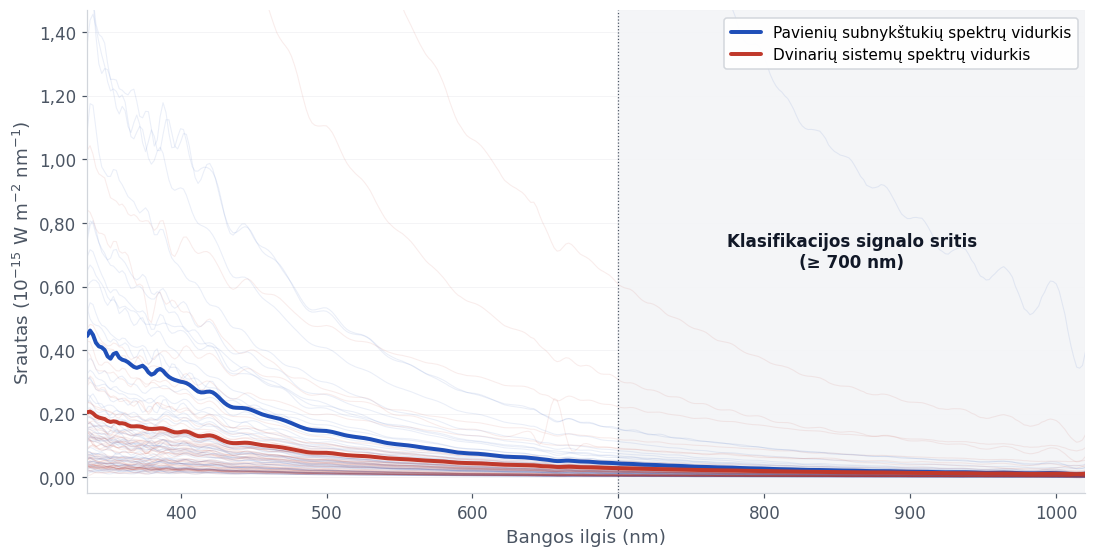

Išsaugota: /Users/erikak/Documents/uni/bakalauras/kodas/thesis_figures/eda/eda-1d_individual_spectra_signal_region_raw.png
Išsaugota: /Users/erikak/Documents/uni/bakalauras/kodas/thesis_figures/eda/eda-1d_individual_spectra_signal_region_raw.svg


In [92]:
FLUX_SCALE = 1e15
flux_unit_label = "Srautas (10$^{-15}$ W m$^{-2}$ nm$^{-1}$)"

SIGNAL_LO = 700.0
signal_mask = xp_wavelengths >= SIGNAL_LO

raw_mean_single = xp_flux_matrix[xp_labels == 0].mean(axis=0)
raw_mean_binary = xp_flux_matrix[xp_labels == 1].mean(axis=0)

fig, ax = plt.subplots(figsize=(10, 5.2))

ax.axvspan(SIGNAL_LO, xp_wavelengths[-1],
           color=ps.GRID_GRAY, alpha=0.85, zorder=0)

for i in single_sample:
    ax.plot(xp_wavelengths, xp_flux_matrix[i] * FLUX_SCALE,
            color=ps.COLORS["single"], alpha=0.09,
            linewidth=0.7, zorder=2)
for i in binary_sample:
    ax.plot(xp_wavelengths, xp_flux_matrix[i] * FLUX_SCALE,
            color=ps.COLORS["binary"], alpha=0.09,
            linewidth=0.7, zorder=2)

ax.fill_between(
    xp_wavelengths,
    raw_mean_single * FLUX_SCALE, raw_mean_binary * FLUX_SCALE,
    where=signal_mask,
    color=ps.COLORS["binary"], alpha=0.18, linewidth=0, zorder=3,
)

ax.plot(xp_wavelengths, raw_mean_single * FLUX_SCALE,
        color=ps.COLORS["single"], linewidth=2.6, linestyle="-",
        label="Pavienių subnykštukių spektrų vidurkis",
        solid_capstyle="round", zorder=5)
ax.plot(xp_wavelengths, raw_mean_binary * FLUX_SCALE,
        color=ps.COLORS["binary"], linewidth=2.6, linestyle="-",
        label="Dvinarių sistemų spektrų vidurkis",
        solid_capstyle="round", zorder=5)

sampled_idx = np.r_[single_sample, binary_sample]
sampled_scaled = xp_flux_matrix[sampled_idx] * FLUX_SCALE
means_scaled = np.concatenate([raw_mean_single, raw_mean_binary]) * FLUX_SCALE

y_lo = float(min(means_scaled.min(),
                 np.percentile(sampled_scaled, 1)))
y_hi = float(max(np.percentile(sampled_scaled, 99), means_scaled.max()))
y_bot = min(y_lo, 0.0) - 0.05
y_top = y_hi * 1.05
ax.set_xlim(xp_wavelengths[0], xp_wavelengths[-1])
ax.set_ylim(y_bot, y_top)

signal_mid_x = float((SIGNAL_LO + xp_wavelengths[-1]) / 2)
signal_mid_y = float((y_bot + y_top) / 2)
ax.text(
    signal_mid_x, signal_mid_y,
    "Klasifikacijos signalo sritis\n(≥ 700 nm)",
    fontsize=11, color=ps.TEXT_DARK, fontweight="bold",
    va="center", ha="center",
)
ax.axvline(SIGNAL_LO, color=ps.TEXT_MUTED, linewidth=0.8,
           linestyle=":", zorder=1)

ps.finalise(
    fig, ax,
    xlabel="Bangos ilgis (nm)",
    ylabel=flux_unit_label,
)
ax.yaxis.set_major_formatter(ps.lt_comma_formatter(decimals=2))
ax.legend(loc="upper right", fontsize=10, frameon=True,
          framealpha=0.95, edgecolor=ps.AXIS_GRAY)

EDA1D_TITLE = (
    "Gaia XP spektrai pagal klases ir jų vidurkiai (absoliutaus srauto skalė) "
    "su klasifikacijos signalo sritimi (≥ 700 nm)"
)
print(f"Paveikslo pavadinimas (kopijuoti į LaTeX caption):\n  {EDA1D_TITLE}\n")

paths = ps.save_fig(fig, "eda-1d_individual_spectra_signal_region_raw")
plt.show()
for p in paths:
    print("Išsaugota:", p)

## Patikrinimas. Santykinis klasių atotrūkis mėlynojoje ir raudonojoje srityse

Empirinis B.I skyriaus 2 pastraipos prielaidos patikrinimas: ar **raudonojoje srityje** santykinis klasių atotrūkis (kiek dvinariai santykinai žemiau pavienių) **mažesnis nei mėlynojoje srityje**? Tai mechaniškai paaiškintų, kodėl po $L_2$ normalizavimo dvinarių vidurkis raudonajame gale iškyla virš pavienių, o mėlynojo gale nusmunka žemiau (persikirtimas ~450 nm matomas EDA-1b/c).

Skaičiavimas:

- `rel_gap(λ) = (mean_single(λ) − mean_binary(λ)) / mean_single(λ)` — kiek dvinariai santykinai žemiau, dalimis nuo pavienių srauto.
- Mėlynoji sritis: [336, 500) nm. Raudonoji sritis: [700, 1020] nm. Tarpinė juosta 500–700 nm sąmoningai paliekama nuošalyje, kad kontrastas tarp dviejų galų būtų aiškus.
- Pateikiamas tiek aritmetinis vidurkis, tiek mediana (atsparesnė triukšmingam raudonajam galui, kur `mean_single` mažas).

Šis blokas yra žvalgomasis – į darbą įdedami tik išvadiniai skaičiai, jei prireiks.

In [93]:
raw_mean_single_chk = xp_flux_matrix[xp_labels == 0].mean(axis=0)
raw_mean_binary_chk = xp_flux_matrix[xp_labels == 1].mean(axis=0)

rel_gap = (raw_mean_single_chk - raw_mean_binary_chk) / raw_mean_single_chk

BLUE_LO, BLUE_HI = 336.0, 500.0
RED_LO,  RED_HI  = 700.0, 1020.0
blue_band = (xp_wavelengths >= BLUE_LO) & (xp_wavelengths < BLUE_HI)
red_band  = (xp_wavelengths >= RED_LO)  & (xp_wavelengths <= RED_HI)

rel_gap_blue_mean   = float(rel_gap[blue_band].mean())
rel_gap_red_mean    = float(rel_gap[red_band].mean())
rel_gap_blue_median = float(np.median(rel_gap[blue_band]))
rel_gap_red_median  = float(np.median(rel_gap[red_band]))

print(f"Mėlynoji sritis  [{BLUE_LO:.0f}, {BLUE_HI:.0f}) nm: "
      f"n_taškų = {int(blue_band.sum())}")
print(f"Raudonoji sritis [{RED_LO:.0f}, {RED_HI:.0f}] nm: "
      f"n_taškų = {int(red_band.sum())}")
print()
print("rel_gap = (mean_single − mean_binary) / mean_single,")
print("aritmetinis vidurkis per sritį:")
print(f"  mėlynoji  : {rel_gap_blue_mean:+.4f}  (~{rel_gap_blue_mean*100:+.1f} %)")
print(f"  raudonoji : {rel_gap_red_mean:+.4f}  (~{rel_gap_red_mean*100:+.1f} %)")
print()
print("Tas pats su mediana (atsparesnė triukšmui raudonajame gale):")
print(f"  mėlynoji  : {rel_gap_blue_median:+.4f}  (~{rel_gap_blue_median*100:+.1f} %)")
print(f"  raudonoji : {rel_gap_red_median:+.4f}  (~{rel_gap_red_median*100:+.1f} %)")
print()

delta_mean   = rel_gap_blue_mean   - rel_gap_red_mean
delta_median = rel_gap_blue_median - rel_gap_red_median
if rel_gap_red_mean < rel_gap_blue_mean and rel_gap_red_median < rel_gap_blue_median:
    print("IŠVADA: rel_gap_red < rel_gap_blue tiek vidurkiu, tiek mediana →")
    print("prielaida PATVIRTINTA.")
    print(f"  Δ (vidurkis) = {delta_mean:+.4f}  (~{delta_mean*100:+.1f} proc. punktų)")
    print(f"  Δ (mediana)  = {delta_median:+.4f}  (~{delta_median*100:+.1f} proc. punktų)")
    print("  → B.I 2 pastraipą galima rašyti tvirtai, įvardinant šiuos skaičius.")
elif rel_gap_red_mean < rel_gap_blue_mean or rel_gap_red_median < rel_gap_blue_median:
    print("IŠVADA: prielaida patvirtinta tik dalinai (vidurkis ir mediana nesutaria) →")
    print("B.I 2 pastraipą rašyti atsargiai, paminint matavimo neapibrėžtumą.")
else:
    print("IŠVADA: rel_gap_red >= rel_gap_blue →")
    print("prielaida NEPATVIRTINTA. B.I 2 pastraipą rašyti atsargiai.")

Mėlynoji sritis  [336, 500) nm: n_taškų = 82
Raudonoji sritis [700, 1020] nm: n_taškų = 161

rel_gap = (mean_single − mean_binary) / mean_single,
aritmetinis vidurkis per sritį:
  mėlynoji  : +0.5142  (~+51.4 %)
  raudonoji : +0.2196  (~+22.0 %)

Tas pats su mediana (atsparesnė triukšmui raudonajame gale):
  mėlynoji  : +0.5133  (~+51.3 %)
  raudonoji : +0.2382  (~+23.8 %)

IŠVADA: rel_gap_red < rel_gap_blue tiek vidurkiu, tiek mediana →
prielaida PATVIRTINTA.
  Δ (vidurkis) = +0.2946  (~+29.5 proc. punktų)
  Δ (mediana)  = +0.2751  (~+27.5 proc. punktų)
  → B.I 2 pastraipą galima rašyti tvirtai, įvardinant šiuos skaičius.


## EDA-2. Po vieną realią pavienę ir dvinarę žvaigždę

Pavyzdiniai (ne vidurkiai) atskirų objektų jungtiniai Gaia XP spektrai. Source_id parametrizuoti notebooko viršuje, kad būtų lengva pakeisti pavyzdį.

Paveikslo pavadinimas (kopijuoti į LaTeX caption):
  Pavyzdiniai pavienės žvaigždės ir dvinarės sistemos Gaia XP spektrai



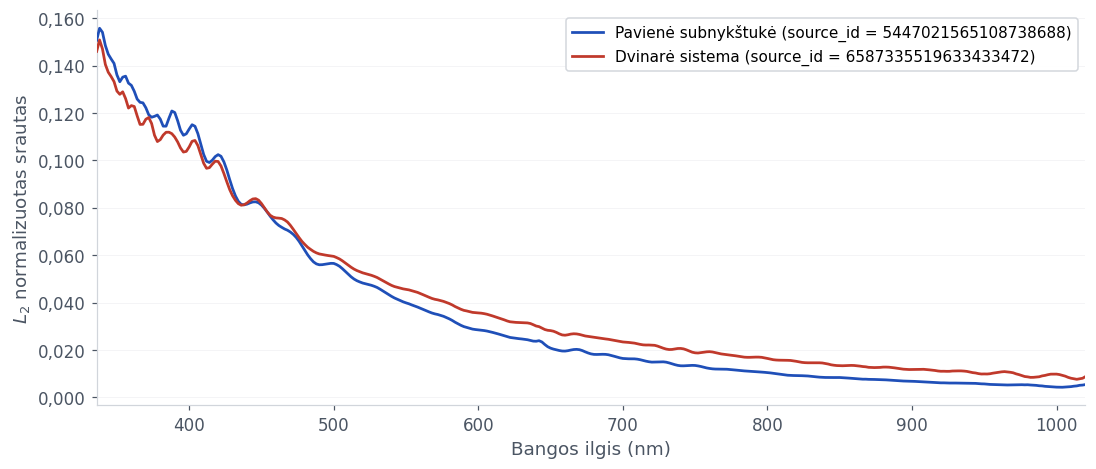

Išsaugota: /Users/erikak/Documents/uni/bakalauras/kodas/thesis_figures/eda/eda-2_single_vs_binary_example.png
Išsaugota: /Users/erikak/Documents/uni/bakalauras/kodas/thesis_figures/eda/eda-2_single_vs_binary_example.svg


In [94]:
def joint_xp_l2_for(source_id: int) -> np.ndarray:
    if source_id not in df_xp_aligned.index:
        raise ValueError(f"source_id={source_id} nėra jungtiniame XP faile")
    flux = df_xp_aligned.loc[source_id, xp_wl_cols].to_numpy(dtype=float)
    norm = float(np.linalg.norm(flux))
    return flux / norm if norm > 0 else flux

single_flux = joint_xp_l2_for(EXAMPLE_SINGLE_SOURCE_ID)
binary_flux = joint_xp_l2_for(EXAMPLE_BINARY_SOURCE_ID)

fig, ax = plt.subplots(figsize=(10, 4.4))
ax.plot(xp_wavelengths, single_flux,
        color=ps.COLORS["single"], linewidth=1.8, linestyle="-",
        label=f"Pavienė subnykštukė (source_id = {EXAMPLE_SINGLE_SOURCE_ID})",
        zorder=3)
ax.plot(xp_wavelengths, binary_flux,
        color=ps.COLORS["binary"], linewidth=1.8, linestyle="-",
        label=f"Dvinarė sistema (source_id = {EXAMPLE_BINARY_SOURCE_ID})",
        zorder=3)

ax.set_xlim(xp_wavelengths[0], xp_wavelengths[-1])

ps.finalise(
    fig, ax,
    xlabel="Bangos ilgis (nm)",
    ylabel="$L_2$ normalizuotas srautas",
)
ax.yaxis.set_major_formatter(ps.lt_comma_formatter(decimals=3))
ax.legend(loc="upper right", fontsize=10, frameon=True,
          framealpha=0.95, edgecolor=ps.AXIS_GRAY)

EDA2_TITLE = "Pavyzdiniai pavienės žvaigždės ir dvinarės sistemos Gaia XP spektrai"
print(f"Paveikslo pavadinimas (kopijuoti į LaTeX caption):\n  {EDA2_TITLE}\n")

paths = ps.save_fig(fig, "eda-2_single_vs_binary_example")
plt.show()
for p in paths:
    print("Išsaugota:", p)

## EDA-3. Klasių pasiskirstymas

Sąrašo dydžiai ir procentinė dalis. Lentelė pateikiama tiek tekstu (pandas DataFrame), tiek LaTeX kodu, kurį galima įklijuoti tiesiai į rašto šaltinį. Papildomai išsaugomas mažas iliustracinis horizontalus stulpelinis grafikas.

                     Klasė Skaičius Dalis (%)
Pavienės žvaigždės (y = 0)    2 257      80.2
 Dvinarės sistemos (y = 1)      558      19.8
                   Iš viso    2 815     100.0

LaTeX lentelė:
\begin{table}[h]
\centering
\caption{Klasių pasiskirstymas pažymėtoje imtyje.}
\label{tab:eda-class-distribution}
\begin{tabular}{lrr}
\toprule
Klasė & Skaičius & Dalis (\%) \\
\midrule
Pavienės žvaigždės (y = 0) & 2\,257 & 80.2 \\
Dvinarės sistemos (y = 1)  & 558 & 19.8 \\
\midrule
Iš viso & 2\,815 & 100.0 \\
\bottomrule
\end{tabular}
\end{table}

Išsaugota: /Users/erikak/Documents/uni/bakalauras/kodas/thesis_figures/eda/eda-3_class_distribution.tex
Paveikslo pavadinimas (kopijuoti į LaTeX caption):
  Klasių pasiskirstymas pažymėtoje imtyje (n = 2815)



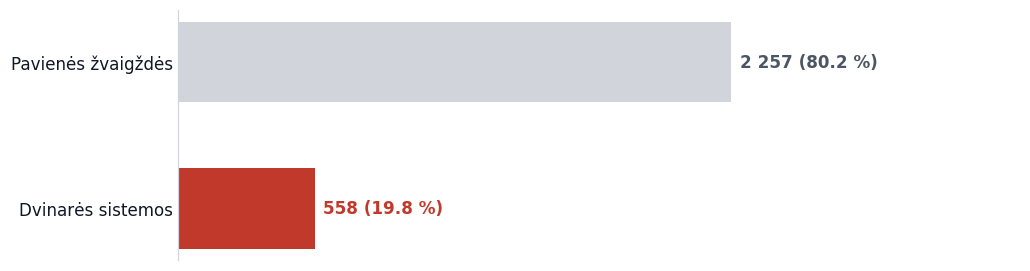

Išsaugota: /Users/erikak/Documents/uni/bakalauras/kodas/thesis_figures/eda/eda-3_class_distribution.png
Išsaugota: /Users/erikak/Documents/uni/bakalauras/kodas/thesis_figures/eda/eda-3_class_distribution.svg


In [95]:
class_df = pd.DataFrame({
    "Klasė": ["Pavienės žvaigždės (y = 0)", "Dvinarės sistemos (y = 1)", "Iš viso"],
    "Skaičius": [n_single, n_binary, n_total],
    "Dalis (%)": [
        100.0 * n_single / n_total,
        100.0 * n_binary / n_total,
        100.0,
    ],
})

display_df = class_df.copy()
display_df["Skaičius"] = display_df["Skaičius"].map("{:,}".format).str.replace(",", " ")
display_df["Dalis (%)"] = display_df["Dalis (%)"].map("{:.1f}".format)
print(display_df.to_string(index=False))

latex_table = (
    "\\begin{table}[h]\n"
    "\\centering\n"
    "\\caption{Klasių pasiskirstymas pažymėtoje imtyje.}\n"
    "\\label{tab:eda-class-distribution}\n"
    "\\begin{tabular}{lrr}\n"
    "\\toprule\n"
    "Klasė & Skaičius & Dalis (\\%) \\\\\n"
    "\\midrule\n"
    f"Pavienės žvaigždės (y = 0) & {n_single:,} & {100.0 * n_single / n_total:.1f} \\\\\n"
    f"Dvinarės sistemos (y = 1)  & {n_binary:,} & {100.0 * n_binary / n_total:.1f} \\\\\n"
    "\\midrule\n"
    f"Iš viso & {n_total:,} & 100.0 \\\\\n"
    "\\bottomrule\n"
    "\\end{tabular}\n"
    "\\end{table}\n"
).replace(",", "\\,")

tex_path = EDA_OUT_DIR / "eda-3_class_distribution.tex"
tex_path.write_text(latex_table, encoding="utf-8")
print("\nLaTeX lentelė:")
print(latex_table)
print("Išsaugota:", tex_path)

fig, ax = plt.subplots(figsize=(9.5, 2.6))
categories = ["Dvinarės sistemos", "Pavienės žvaigždės"]
counts = [n_binary, n_single]
bar_colors = [ps.COLORS["binary"], ps.AXIS_GRAY]
bars = ax.barh(categories, counts, color=bar_colors, height=0.55, edgecolor="none")

for bar, count in zip(bars, counts):
    pct = 100.0 * count / n_total
    label_color = ps.COLORS["binary"] if bar is bars[0] else ps.TEXT_MUTED
    ax.text(bar.get_width() + n_total * 0.012,
            bar.get_y() + bar.get_height() / 2,
            f"{count:,} ({pct:.1f} %)".replace(",", " "),
            ha="left", va="center", fontweight="bold",
            fontsize=11, color=label_color)

ax.set_xlim(0, n_total * 1.22)
ax.xaxis.set_visible(False)
for spine in ("top", "right", "bottom"):
    ax.spines[spine].set_visible(False)
ax.spines["left"].set_color(ps.AXIS_GRAY)
ax.tick_params(axis="y", length=0, labelsize=11, colors=ps.TEXT_DARK)
fig.tight_layout()

EDA3_TITLE = f"Klasių pasiskirstymas pažymėtoje imtyje (n = {n_total})"
print(f"Paveikslo pavadinimas (kopijuoti į LaTeX caption):\n  {EDA3_TITLE}\n")

paths = ps.save_fig(fig, "eda-3_class_distribution")
plt.show()
for p in paths:
    print("Išsaugota:", p)

## EDA-4. Čebiševo aproksimacija prie skirtingų K (BP ir RP segmentai atskirai)

Vienos pavienės žvaigždės BP spektras (336–642 nm) ir RP spektras (636–1020 nm) bei jų Čebiševo bazės rekonstrukcijos prie K ∈ {2, 5, 10, 20}. K augimą iliustruoja mėlynos atspalvio gradacija: nuo šviesaus iki tamsiai mėlyno. Abu segmentai aproksimuojami atskirai – taip pat, kaip pagrindiniame klasifikacijos vamzdyne (`02_generate_basis_features.py`): kiekvienas segmentas nepriklausomai L2 normalizuojama ir paklotai parenkami K koeficientų, vėliau bruožai sujungiami į [BP | RP] vektorių, kurio ilgis 2K. Skydeliai pasidaryti proporcingo pločio, kad bangos ilgių skalė tarp jų išliktų sąžininga, ir dalijasi $L_2$ srauto ašimi.

Paveikslo pavadinimas (kopijuoti į LaTeX caption):
  BP ir RP spektrų Čebiševo aproksimacija didėjant koeficientų skaičiui K (source_id = 5447021565108738688)



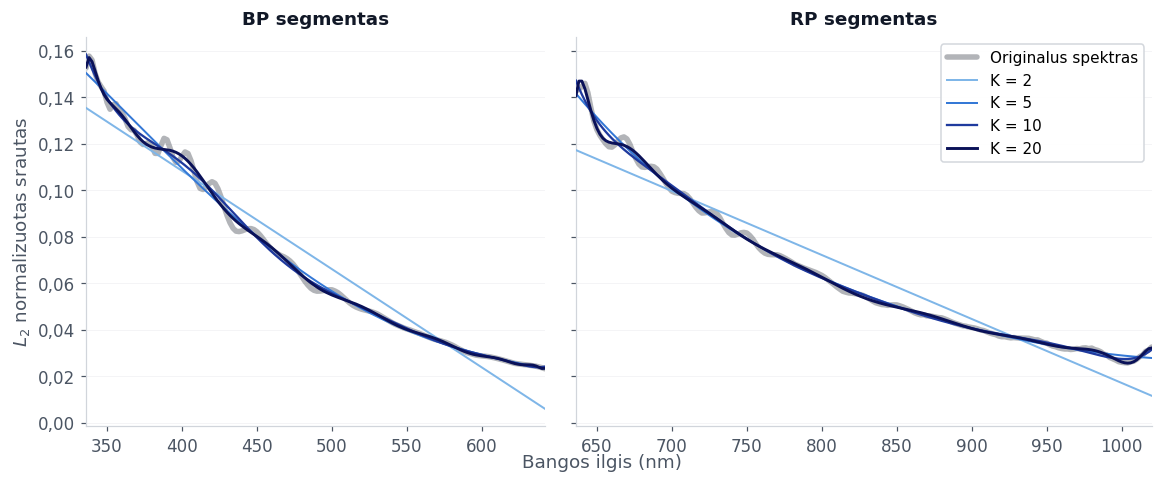

Išsaugota: /Users/erikak/Documents/uni/bakalauras/kodas/thesis_figures/eda/eda-4_chebyshev_varying_K.png
Išsaugota: /Users/erikak/Documents/uni/bakalauras/kodas/thesis_figures/eda/eda-4_chebyshev_varying_K.svg


In [96]:
bp_idx = row_index(bp, EXAMPLE_SINGLE_SOURCE_ID)
rp_idx = row_index(rp, EXAMPLE_SINGLE_SOURCE_ID)
bp_flux_one = bp.flux[bp_idx]
rp_flux_one = rp.flux[rp_idx]

bp_range = float(bp.wavelengths[-1] - bp.wavelengths[0])
rp_range = float(rp.wavelengths[-1] - rp.wavelengths[0])

fig, (ax_bp, ax_rp) = plt.subplots(
    1, 2, figsize=(12.5, 4.6),
    sharey=True,
    gridspec_kw={"width_ratios": [bp_range, rp_range], "wspace": 0.06},
)

k_colors = ps.COLORS["k_seq"]
if len(k_colors) < len(K_LIST_FOR_EDA4):
    raise ValueError("Sekvencinė K spalvų paletė per trumpa")

RAW_BG_COLOR = "#555a63"
RAW_BG_ALPHA = 0.45
K_LINEWIDTHS = {2: 1.3, 5: 1.3, 10: 1.5, 20: 1.9}

for ax, block, flux_one, panel_title in [
    (ax_bp, bp, bp_flux_one, "BP segmentas"),
    (ax_rp, rp, rp_flux_one, "RP segmentas"),
]:
    ax.plot(block.wavelengths, flux_one,
            color=RAW_BG_COLOR, linewidth=3.6, linestyle="-",
            alpha=RAW_BG_ALPHA, solid_capstyle="round",
            label="Originalus spektras", zorder=1)
    for k_val, color in zip(K_LIST_FOR_EDA4, k_colors):
        coeffs = step02.fit_basis(block.wavelengths, flux_one, "chebyshev", k_val)
        recon = step02.reconstruct_flux(block.wavelengths, coeffs, "chebyshev")
        ax.plot(block.wavelengths, recon,
                color=color, linewidth=K_LINEWIDTHS[k_val], linestyle="-",
                label=f"K = {k_val}", zorder=3 + k_val * 0.001)
    ax.set_xlim(block.wavelengths[0], block.wavelengths[-1])
    ps.apply_style(ax)
    ax.set_title(panel_title, fontsize=12, fontweight="bold",
                 color=ps.TEXT_DARK, loc="center", pad=8)

ax_bp.set_ylabel("$L_2$ normalizuotas srautas", fontsize=12, color=ps.TEXT_MUTED)
ax_bp.yaxis.set_major_formatter(ps.lt_comma_formatter(decimals=2))
fig.supxlabel("Bangos ilgis (nm)", fontsize=12, color=ps.TEXT_MUTED, y=0.02)

ax_rp.legend(loc="upper right", fontsize=10, frameon=True,
             framealpha=0.95, edgecolor=ps.AXIS_GRAY, ncol=1)

EDA4_TITLE = (
    f"BP ir RP spektrų Čebiševo aproksimacija didėjant koeficientų skaičiui K "
    f"(source_id = {EXAMPLE_SINGLE_SOURCE_ID})"
)
print(f"Paveikslo pavadinimas (kopijuoti į LaTeX caption):\n  {EDA4_TITLE}\n")

paths = ps.save_fig(fig, "eda-4_chebyshev_varying_K")
plt.show()
for p in paths:
    print("Išsaugota:", p)

## EDA-5. Trys bazės prie fiksuoto K = 20 (BP ir RP segmentai atskirai)

Tie patys BP ir RP spektrai, kaip ir EDA-4, bet dabar su trijų skirtingų bazių rekonstrukcijomis prie K = 20: Čebiševo, Ležandro ir B-splainų. Kiekvienas segmentas aproksimuojamas atskirai – kaip ir pagrindiniame klasifikacijos vamzdyne. Skirtingos spalvos, linijos stilius ir žymekliai užtikrina, kad kreivės skiriasi ir spausdinant pilkais atspalviais. Skydeliai pasidaryti proporcingo pločio bangos ilgių skalės atžvilgiu ir dalijasi $L_2$ srauto ašimi.

Paveikslo pavadinimas (kopijuoti į LaTeX caption):
  Trijų bazių aproksimacijos vienai žvaigždei (K = 20, BP ir RP segmentai atskirai, source_id = 5447021565108738688)



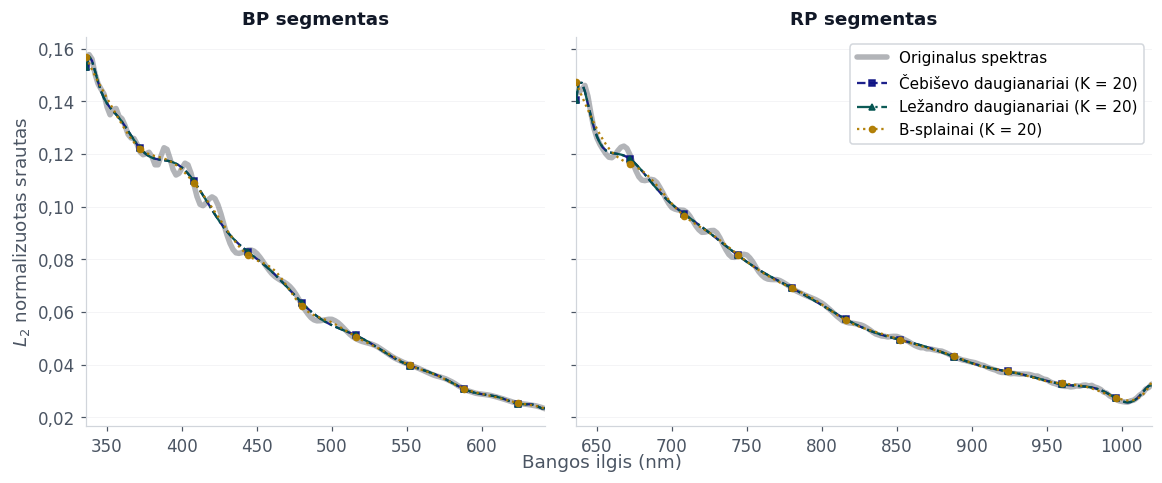

Išsaugota: /Users/erikak/Documents/uni/bakalauras/kodas/thesis_figures/eda/eda-5_three_bases_K20.png
Išsaugota: /Users/erikak/Documents/uni/bakalauras/kodas/thesis_figures/eda/eda-5_three_bases_K20.svg


In [97]:
bp_idx = row_index(bp, EXAMPLE_SINGLE_SOURCE_ID)
rp_idx = row_index(rp, EXAMPLE_SINGLE_SOURCE_ID)
bp_flux_one = bp.flux[bp_idx]
rp_flux_one = rp.flux[rp_idx]

bp_range = float(bp.wavelengths[-1] - bp.wavelengths[0])
rp_range = float(rp.wavelengths[-1] - rp.wavelengths[0])

fig, (ax_bp, ax_rp) = plt.subplots(
    1, 2, figsize=(12.5, 4.6),
    sharey=True,
    gridspec_kw={"width_ratios": [bp_range, rp_range], "wspace": 0.06},
)

RAW_BG_COLOR = "#555a63"
RAW_BG_ALPHA = 0.45

# Mapping for legend label renaming from "polinomai" to "daugianariai"
def legend_label_lt(basis_name_lt):
    return basis_name_lt.replace("polinomai", "daugianariai")

for ax, block, flux_one, panel_title, show_labels in [
    (ax_bp, bp, bp_flux_one, "BP segmentas", False),
    (ax_rp, rp, rp_flux_one, "RP segmentas", True),
]:
    ax.plot(block.wavelengths, flux_one,
            color=RAW_BG_COLOR, linewidth=3.6, linestyle="-",
            alpha=RAW_BG_ALPHA, solid_capstyle="round",
            label=("Originalus spektras" if show_labels else None),
            zorder=1)
    for basis in BASES:
        coeffs = step02.fit_basis(block.wavelengths, flux_one, basis, K_FIXED)
        recon = step02.reconstruct_flux(block.wavelengths, coeffs, basis)
        legend_text = None
        if show_labels:
            legend_text = f"{legend_label_lt(ps.BASES_LT[basis])} (K = {K_FIXED})"
        ax.plot(block.wavelengths, recon,
                color=ps.COLORS[basis],
                linewidth=1.5,
                linestyle=ps.LINESTYLES[basis],
                marker=ps.MARKERS[basis], markersize=4, markevery=18,
                label=legend_text,
                alpha=0.95, zorder=3)
    ax.set_xlim(block.wavelengths[0], block.wavelengths[-1])
    ps.apply_style(ax)
    ax.set_title(panel_title, fontsize=12, fontweight="bold",
                 color=ps.TEXT_DARK, loc="center", pad=8)

ax_bp.set_ylabel("$L_2$ normalizuotas srautas", fontsize=12, color=ps.TEXT_MUTED)
ax_bp.yaxis.set_major_formatter(ps.lt_comma_formatter(decimals=2))
fig.supxlabel("Bangos ilgis (nm)", fontsize=12, color=ps.TEXT_MUTED, y=0.02)

ax_rp.legend(loc="upper right", fontsize=10, frameon=True,
             framealpha=0.95, edgecolor=ps.AXIS_GRAY, ncol=1)

EDA5_TITLE = (
    f"Trijų bazių aproksimacijos vienai žvaigždei (K = {K_FIXED}, BP ir RP segmentai "
    f"atskirai, source_id = {EXAMPLE_SINGLE_SOURCE_ID})"
)
print(f"Paveikslo pavadinimas (kopijuoti į LaTeX caption):\n  {EDA5_TITLE}\n")

paths = ps.save_fig(fig, "eda-5_three_bases_K20")
plt.show()
for p in paths:
    print("Išsaugota:", p)

## EDA-6. Vidutinė aproksimacijos paklaida priklausomai nuo K (BP ir RP segmentai atskirai)

Kiekvienai bazei (Čebiševo, Ležandro daugianariai ir B-splainai) ir kiekvienam $K \in \{2, 5, 10, 15, 20\}$ skaičiuojama 2 815 žvaigždžių rekonstrukcijų **vidutinė** $R^2$ reikšmė **atskirai BP ir RP segmentams**, taip pat, kaip jie traktuojami klasifikacijos vamzdyne (kiekvienas segmentas pritaikomas nepriklausomai, gaunant $K + K = 2K$ koeficientų bruožų vektorių). Skydeliai pateikia $1 - \bar{R^2}$ logaritmine skale: kairysis – BP, dešinysis – RP. $K$ reikšmių rinkinys tiksliai atitinka tą, kuris naudojamas eksperimentuose, todėl paveikslas neperžengia tikrosios eksperimentinės srities.

B-splainų kreivė kiekviename segmente prasideda nuo $K = 5$, nes kubinių splainų pritaikymui reikia bent $K \geq \text{laipsnis} + 2 = 5$ kontrolinių taškų; mažesnės $K$ reikšmės jiems matematiškai neapibrėžtos. Čebiševo ir Ležandro daugianariai dengia tą pačią daugianarių erdvę, todėl jų mažiausių kvadratų rekonstrukcijos sutampa ir kreivės persidengia abiejuose segmentuose — skiriasi tik koeficientų atvaizdavimas (žr. EDA-7).

Skaičiavimas talpinamas į `bp_rp_basis_experiment/data/eda6_mean_r2.csv` (su `arm`, `basis`, `K`, `mean_r2` stulpeliais), kad pakartotinis paleidimas vyktų akimirksniu.

In [98]:
EDA6_CACHE = WORKSPACE_ROOT / "bp_rp_basis_experiment" / "data" / "eda6_mean_r2.csv"

BSPLINE_MIN_K = 5

def fit_block_coeffs(block, basis: str, k: int) -> np.ndarray:
    """Sukuria N x K koeficientų matricą visai imčiai naudojant `step02`."""
    if basis in step02.POLY_BASES:
        coeffs = np.empty((block.flux.shape[0], k), dtype=float)
        for i in range(block.flux.shape[0]):
            coeffs[i] = step02.fit_basis(block.wavelengths, block.flux[i], basis, k)
        return coeffs
    design = step02.basis_design_matrix(block.wavelengths, basis=basis, n_coeffs=k)
    coeffs, *_ = np.linalg.lstsq(design, block.flux.T, rcond=None)
    return coeffs.T

def reconstruct_block(block, coeffs: np.ndarray, basis: str) -> np.ndarray:
    design = step02.basis_design_matrix(block.wavelengths, basis=basis, n_coeffs=coeffs.shape[1])
    return coeffs @ design.T

def mean_r2_for(block, basis: str, k: int) -> float:
    coeffs = fit_block_coeffs(block, basis, k)
    recon = reconstruct_block(block, coeffs, basis)
    metrics = step02.compute_metric_arrays(block.flux, recon)
    return float(np.nanmean(metrics["r2"]))

def k_grid_for(basis: str) -> list[int]:
    if basis == "bspline":
        return [k for k in K_GRID_FOR_EDA6 if k >= BSPLINE_MIN_K]
    return list(K_GRID_FOR_EDA6)

ARM_BLOCKS = [("BP", bp), ("RP", rp)]

def _cache_is_compatible(df: pd.DataFrame) -> bool:
    required = {"arm", "basis", "K", "mean_r2"}
    if not required.issubset(df.columns):
        return False
    if set(df["arm"].unique()) != {"BP", "RP"}:
        return False
    if set(df["K"].unique()) != set(K_GRID_FOR_EDA6) | (set(K_GRID_FOR_EDA6) - {2}):
        # K=2 is absent for B-splines by design; allow that case
        pass
    return True

eda6_df = None
if EDA6_CACHE.exists():
    cached = pd.read_csv(EDA6_CACHE)
    if _cache_is_compatible(cached):
        eda6_df = cached
        print(f"Įkeltas talpyklos failas: {EDA6_CACHE}")
    else:
        print(f"Talpykla {EDA6_CACHE} nesuderinama su nauja schema – perskaičiuojama.")

if eda6_df is None:
    rows = []
    for arm_name, block in ARM_BLOCKS:
        for basis in BASES:
            for k in k_grid_for(basis):
                r2 = mean_r2_for(block, basis, k)
                rows.append({"arm": arm_name, "basis": basis, "K": k, "mean_r2": r2})
                print(f"  arm={arm_name} basis={basis:10s} K={k:3d}  mean R^2 = {r2:.5f}")
    eda6_df = pd.DataFrame(rows)
    EDA6_CACHE.parent.mkdir(parents=True, exist_ok=True)
    eda6_df.to_csv(EDA6_CACHE, index=False)
    print(f"Talpyklos failas išsaugotas: {EDA6_CACHE}")

eda6_df["one_minus_r2"] = 1.0 - eda6_df["mean_r2"]

print("\nVidutinis R^2 pagal segmentą ir bazę:")
for arm_name, _ in ARM_BLOCKS:
    print(f"\n  [{arm_name} segmentas]")
    pivot = (eda6_df[eda6_df["arm"] == arm_name]
             .pivot(index="K", columns="basis", values="mean_r2")
             .round(5))
    print(pivot)

print(
    "\nPastaba: Čebiševo ir Ležandro bazės dengia tą pačią daugianarių erdvę, "
    "todėl jų mažiausių kvadratų rekonstrukcijos sutampa imties mastu, ir "
    "vidutinis $R^2$ joms yra identiškas. Skiriasi tik koeficientų atvaizdavimas "
    "(žr. EDA-7)."
)

Įkeltas talpyklos failas: /Users/erikak/Documents/uni/bakalauras/kodas/bp_rp_basis_experiment/data/eda6_mean_r2.csv

Vidutinis R^2 pagal segmentą ir bazę:

  [BP segmentas]
basis  bspline  chebyshev  legendre
K                                  
2          NaN    0.92472   0.92472
5      0.98270    0.98253   0.98253
10     0.98715    0.98730   0.98730
15     0.98885    0.98880   0.98880
20     0.98969    0.98993   0.98993

  [RP segmentas]
basis  bspline  chebyshev  legendre
K                                  
2          NaN    0.90309   0.90309
5      0.97211    0.97241   0.97241
10     0.97891    0.98023   0.98023
15     0.98323    0.98575   0.98575
20     0.98711    0.98950   0.98950

Pastaba: Čebiševo ir Ležandro bazės dengia tą pačią daugianarių erdvę, todėl jų mažiausių kvadratų rekonstrukcijos sutampa imties mastu, ir vidutinis $R^2$ joms yra identiškas. Skiriasi tik koeficientų atvaizdavimas (žr. EDA-7).


Paveikslo pavadinimas (kopijuoti į LaTeX caption):
  Vidutinės aproksimacijos paklaidos $1 - \bar{R^2}$ priklausomybė nuo koeficientų skaičiaus $K$ (BP ir RP segmentai atskirai, n = 2 815). Čebiševo ir Ležandro daugianariai sutampa, nes abi bazės dengia tą pačią daugianarių erdvę.



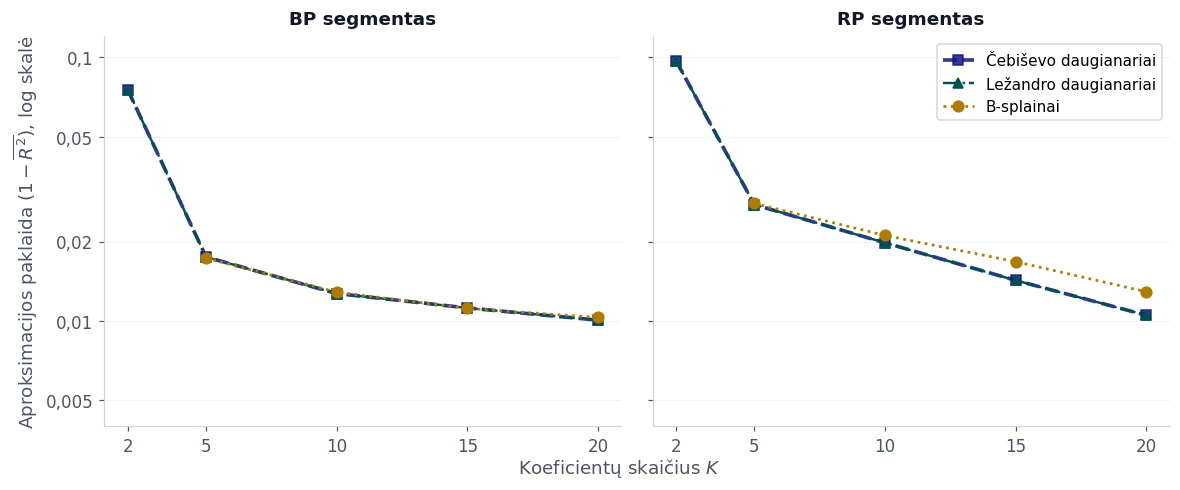

Išsaugota: /Users/erikak/Documents/uni/bakalauras/kodas/thesis_figures/eda/eda-6_mean_r2_vs_K.png
Išsaugota: /Users/erikak/Documents/uni/bakalauras/kodas/thesis_figures/eda/eda-6_mean_r2_vs_K.svg


In [102]:
from matplotlib.ticker import FixedLocator, FuncFormatter, NullLocator

BASIS_ORDER = ("chebyshev", "legendre", "bspline")
BASIS_LW = {"chebyshev": 2.4, "legendre": 1.6, "bspline": 1.8}
BASIS_ALPHA = {"chebyshev": 0.85, "legendre": 1.0, "bspline": 1.0}
BASIS_ZORDER = {"chebyshev": 3, "legendre": 4, "bspline": 5}

Y_TICKS = [0.005, 0.01, 0.02, 0.05, 0.1]

def _fmt_lt_log(value: float, _pos: int) -> str:
    s = f"{value:.3f}".rstrip("0").rstrip(".")
    return s.replace(".", ",")

fig, (ax_bp, ax_rp) = plt.subplots(
    1, 2, figsize=(12.5, 4.6),
    sharey=True,
    gridspec_kw={"wspace": 0.06},
)

for ax, arm_name, panel_title, show_labels in [
    (ax_bp, "BP", "BP segmentas", False),
    (ax_rp, "RP", "RP segmentas", True),
]:
    for basis in BASIS_ORDER:
        sub = (eda6_df[(eda6_df["arm"] == arm_name) & (eda6_df["basis"] == basis)]
               .sort_values("K"))
        if sub.empty:
            continue
        ax.plot(
            sub["K"], sub["one_minus_r2"].clip(lower=1e-7),
            color=ps.COLORS[basis],
            linestyle=ps.LINESTYLES[basis],
            marker=ps.MARKERS[basis],
            markersize=7,
            linewidth=BASIS_LW[basis],
            alpha=BASIS_ALPHA[basis],
            label=(ps.BASES_LT[basis] if show_labels else None),
            zorder=BASIS_ZORDER[basis],
        )
    ax.set_yscale("log")
    ax.set_xticks(K_GRID_FOR_EDA6)
    ax.set_ylim(0.004, 0.12)
    ax.yaxis.set_major_locator(FixedLocator(Y_TICKS))
    ax.yaxis.set_minor_locator(NullLocator())
    ax.yaxis.set_major_formatter(FuncFormatter(_fmt_lt_log))
    ps.apply_style(ax, grid_axis="y")
    ax.grid(axis="y", which="major", color="#eef0f3", linewidth=0.5,
            linestyle="-", zorder=0)
    ax.set_title(panel_title, fontsize=12, fontweight="bold",
                 color=ps.TEXT_DARK, loc="center", pad=8)

ax_bp.set_ylabel(r"Aproksimacijos paklaida $(1 - \overline{R^{2}})$, log skalė",
                 fontsize=12, color=ps.TEXT_MUTED)
# Move x-axis title lower by decreasing the y argument (default is 0.02)
fig.supxlabel("Koeficientų skaičius $K$", fontsize=12, color=ps.TEXT_MUTED, y=0.005)

ax_rp.legend(loc="upper right", fontsize=10, frameon=True,
             framealpha=0.95, edgecolor=ps.AXIS_GRAY)

EDA6_TITLE = (
    "Vidutinės aproksimacijos paklaidos $1 - \\bar{R^2}$ priklausomybė nuo "
    "koeficientų skaičiaus $K$ (BP ir RP segmentai atskirai, n = 2 815). "
    "Čebiševo ir Ležandro daugianariai sutampa, nes abi bazės dengia tą "
    "pačią daugianarių erdvę."
)
print(f"Paveikslo pavadinimas (kopijuoti į LaTeX caption):\n  {EDA6_TITLE}\n")

paths = ps.save_fig(fig, "eda-6_mean_r2_vs_K")
plt.show()
for p in paths:
    print("Išsaugota:", p)

## EDA-7. Empirinė koeficientų koreliacijos matrica (RP ir BP atskirai)

Šeši skydeliai išdėstyti $2 \times 3$ tinkleliu — viršutinė eilutė: **RP** segmentas, apatinė: **BP** segmentas; stulpeliai atitinka tris bazes (Čebiševo, Ležandro, B-splainų). Kiekvieno skydelio matrica yra $K \times K = 20 \times 20$ ir skaičiuojama taip:

1. Kiekvienai bazei prie $K = 20$ abiem segmentams (BP ir RP) pritaikomas mažiausių kvadratų pritaikymas, gaunama 2 815 × $K$ koeficientų matrica kiekvienam segmentui.
2. BP ir RP koeficientai sujungiami į vieną 2 815 × $2K$ bruožų vektorių (BP koeficientai eilutės pradžioje, RP gale) ir atliekamas **eilutės $L_2$ normalizavimas**. Tai yra tas pats bruožų vektorius, kurį priima klasifikatoriai (`08_kbp_krp_grid_*.py`).
3. Suskaičiuojama 2$K \times $2$K$ Pirsono koreliacijos matrica, ir parodomi du jos įstrižaininiai blokai: BP × BP (apačioje) ir RP × RP (viršuje).

Tokiu būdu rodoma koreliacija atspindi būtent klasifikavimo įvestį (žr. `12_bspline_multicollinearity.ipynb`), o atskyrimas pagal segmentą leidžia lengviau matyti vieno segmento vidinę bazės struktūrą. Ryški juostinė struktūra B-splainų atveju iliustruoja lokalų bazinių funkcijų pobūdį; Čebiševo ir Ležandro daugianarių matricose juostinė struktūra **silpnesnė**, tačiau jokiu būdu ne nulinė. Pavadinime ir paantraštėse aiškiai pažymėta, kad parodyta būtent **empirinė** koreliacija per imtį, o ne teorinis bazinių funkcijų ortogonalumas.

In [105]:
def concat_bp_rp_features(basis: str, k: int) -> np.ndarray:
    """L2 normalizuoti [BP | RP] bruožai — toks pats vektorius, kokį priima
    `08_kbp_krp_grid_*.py` klasifikatoriai (žr. 12_bspline_multicollinearity.ipynb).
    """
    bp_fit = step02.build_block_fit(bp, basis, "none", k)
    rp_fit = step02.build_block_fit(rp, basis, "none", k)
    stacked = np.hstack([bp_fit.coeffs, rp_fit.coeffs])
    cols = [f"c{i:03d}" for i in range(stacked.shape[1])]
    df = pd.DataFrame(stacked, columns=cols)
    df = l2_normalize(df, coeff_cols=cols)
    return df[cols].to_numpy(dtype=np.float64)


coeff_matrices: dict[str, np.ndarray] = {}
corr_matrices: dict[str, np.ndarray] = {}
off_diag_summary: dict[str, dict[str, dict[str, float]]] = {}

within_arm_mask = ~np.eye(K_FIXED, dtype=bool)


def _abs_stats(block: np.ndarray, mask: np.ndarray | None = None) -> dict[str, float]:
    """Mean / median / min / max of the absolute correlation values.

    `mask` selects which cells of `block` to include; if None, all cells are used
    (used for the BP × RP cross block, which has no self-correlation diagonal).
    """
    vals = np.abs(block[mask] if mask is not None else block).ravel()
    return {
        "mean":   float(vals.mean()),
        "median": float(np.median(vals)),
        "min":    float(vals.min()),
        "max":    float(vals.max()),
    }


for basis in BASES:
    X = concat_bp_rp_features(basis, K_FIXED)
    coeff_matrices[basis] = X
    corr = np.corrcoef(X.T)
    corr_matrices[basis] = corr

    blocks = {
        "BP-BP":   _abs_stats(corr[:K_FIXED, :K_FIXED], within_arm_mask),
        "RP-RP":   _abs_stats(corr[K_FIXED:, K_FIXED:], within_arm_mask),
        "BP × RP": _abs_stats(corr[:K_FIXED, K_FIXED:], None),
    }
    off_diag_summary[basis] = blocks

    print(f"{basis:10s}: bruožų matrica {X.shape} ([BP | RP], L2 normalizuota)")
    print(f"            |off-diag corr| statistika (visada apie absoliutų dydį):")
    for label, st in blocks.items():
        print(f"              {label:8s}  vid={st['mean']:.3f}   "
              f"mediana={st['median']:.3f}   min={st['min']:.3f}   "
              f"max={st['max']:.3f}")

chebyshev : bruožų matrica (2815, 40) ([BP | RP], L2 normalizuota)
            |off-diag corr| statistika (visada apie absoliutų dydį):
              BP-BP     vid=0.345   mediana=0.279   min=0.000   max=0.957
              RP-RP     vid=0.467   mediana=0.476   min=0.008   max=0.946
              BP × RP   vid=0.047   mediana=0.023   min=0.000   max=0.888
legendre  : bruožų matrica (2815, 40) ([BP | RP], L2 normalizuota)
            |off-diag corr| statistika (visada apie absoliutų dydį):
              BP-BP     vid=0.351   mediana=0.323   min=0.001   max=0.936
              RP-RP     vid=0.430   mediana=0.422   min=0.001   max=0.945
              BP × RP   vid=0.057   mediana=0.029   min=0.000   max=0.950
bspline   : bruožų matrica (2815, 40) ([BP | RP], L2 normalizuota)
            |off-diag corr| statistika (visada apie absoliutų dydį):
              BP-BP     vid=0.699   mediana=0.730   min=0.001   max=0.998
              RP-RP     vid=0.316   mediana=0.299   min=0.004   max=0.864


Paveikslo pavadinimas (kopijuoti į LaTeX caption):
  Empirinė koeficientų koreliacijos matrica trijų bazių atveju — per segmentus atskirai (RP viršuje, BP apačioje, $L_2$ normalizuoti [BP | RP] bruožai, n = 2 815, K = 20)



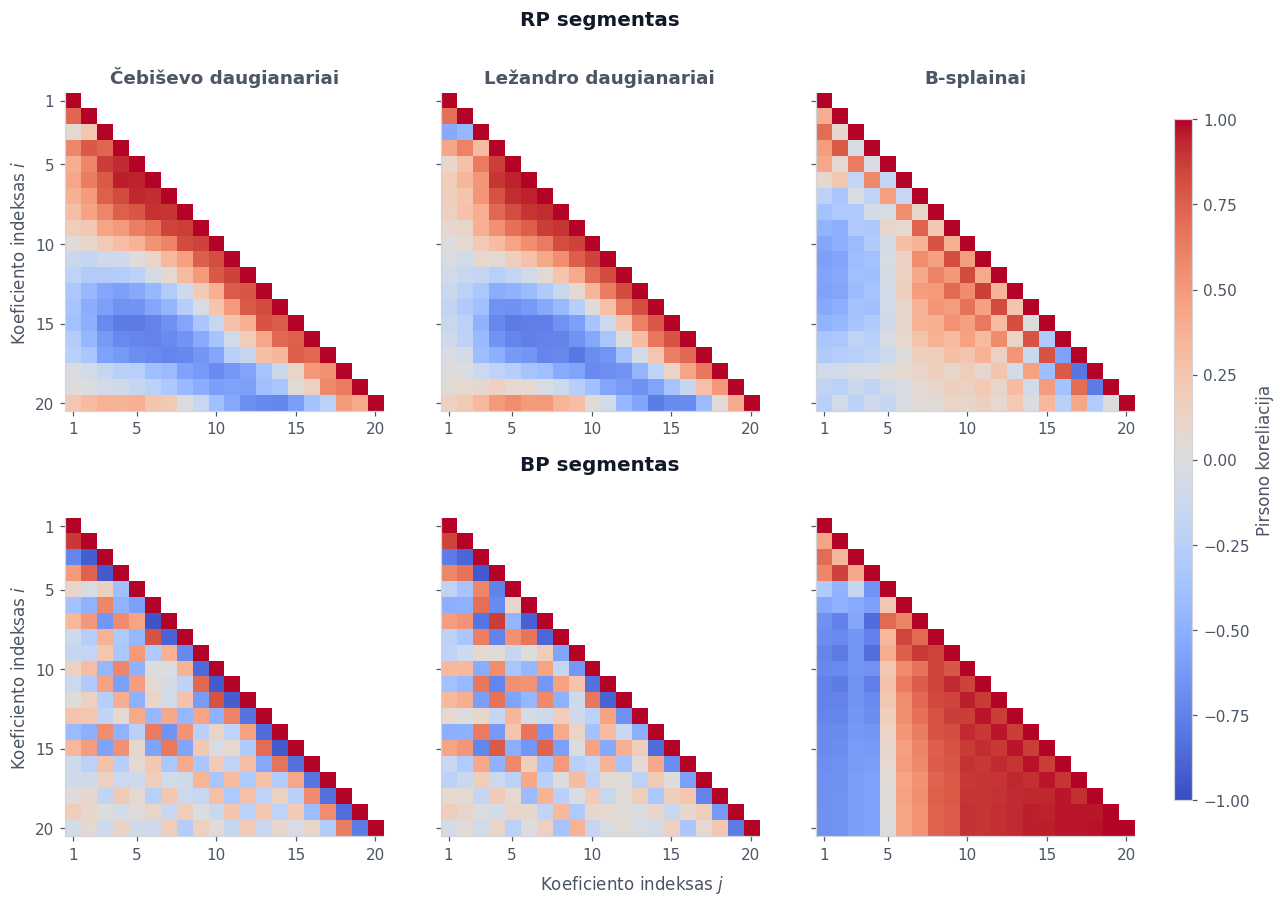

Išsaugota: /Users/erikak/Documents/uni/bakalauras/kodas/thesis_figures/eda/eda-7_coef_correlation.png
Išsaugota: /Users/erikak/Documents/uni/bakalauras/kodas/thesis_figures/eda/eda-7_coef_correlation.svg


In [107]:
ordered = ["chebyshev", "legendre", "bspline"]
arm_rows = [
    ("RP segmentas", lambda c: c[K_FIXED:, K_FIXED:]),
    ("BP segmentas", lambda c: c[:K_FIXED, :K_FIXED]),
]
tick_positions = [0, 4, 9, 14, 19]
tick_labels = ["1", "5", "10", "15", "20"]

corr_cmap = plt.get_cmap("coolwarm").copy()
corr_cmap.set_bad(color="white")

fig, axes = plt.subplots(2, 3, figsize=(12.0, 8.6), sharex=True, sharey=True)

ims = []
for row_idx, (row_title, slicer) in enumerate(arm_rows):
    for col_idx, basis in enumerate(ordered):
        ax = axes[row_idx, col_idx]
        block = slicer(corr_matrices[basis])
        upper_mask = np.triu(np.ones_like(block, dtype=bool), k=1)
        block_tri = np.ma.masked_array(block, mask=upper_mask)
        im = ax.imshow(
            block_tri,
            vmin=-1, vmax=1, cmap=corr_cmap,
            origin="upper", interpolation="nearest",
        )
        ims.append(im)

        ax.set_xticks(tick_positions)
        ax.set_xticklabels(tick_labels)
        ax.set_yticks(tick_positions)
        ax.set_yticklabels(tick_labels)
        ax.tick_params(axis="both", labelsize=10, colors=ps.TEXT_MUTED,
                       labelbottom=True)
        for spine in ax.spines.values():
            spine.set_color(ps.AXIS_GRAY)
            spine.set_linewidth(0.8)

        if row_idx == 0:
            ax.set_title(
                ps.BASES_LT[basis],
                fontsize=12, color=ps.TEXT_MUTED, pad=6,
            )
        if col_idx == 0:
            ax.set_ylabel(
                "Koeficiento indeksas $i$",
                fontsize=11, color=ps.TEXT_MUTED,
            )

fig.supxlabel(
    "Koeficiento indeksas $j$",
    fontsize=11, color=ps.TEXT_MUTED, y=0.03,
)

fig.subplots_adjust(left=0.07, right=0.88, top=0.88, bottom=0.09,
                    hspace=0.32, wspace=0.18)

axes_center_x = (0.07 + 0.88) / 2
fig.text(axes_center_x, 0.955, arm_rows[0][0],
         ha="center", va="center",
         fontsize=13, fontweight="bold", color=ps.TEXT_DARK)
fig.text(axes_center_x, 0.485, arm_rows[1][0],
         ha="center", va="center",
         fontsize=13, fontweight="bold", color=ps.TEXT_DARK)

cbar_ax = fig.add_axes([0.91, 0.13, 0.014, 0.72])
cbar = fig.colorbar(ims[-1], cax=cbar_ax)
cbar.set_label("Pirsono koreliacija", fontsize=11, color=ps.TEXT_MUTED)
cbar.ax.tick_params(labelsize=10, colors=ps.TEXT_MUTED)
cbar.outline.set_edgecolor(ps.AXIS_GRAY)

EDA7_TITLE = (
    "Empirinė koeficientų koreliacijos matrica trijų bazių atveju — "
    f"per segmentus atskirai (RP viršuje, BP apačioje, $L_2$ normalizuoti "
    f"[BP | RP] bruožai, n = 2 815, K = {K_FIXED})"
)
print(f"Paveikslo pavadinimas (kopijuoti į LaTeX caption):\n  {EDA7_TITLE}\n")

paths = ps.save_fig(fig, "eda-7_coef_correlation")
plt.show()
for p in paths:
    print("Išsaugota:", p)